# Recap

- Что такое Transfert learning


<!-- Модель, обученная на одной задаче, используется в другой -->

- Что такое Fine Tuning?

<!--  -->

- Чем отличаются подходы One Shot И Few Shot

- В чем основная новизна подхода Bert?

- В чем состоит метод дообучения LLM LoRA (LowRankAdapt)

- что такое системный промт?

# Работа с LLM

### Zero-shot

Zero-shot промптинг — это режим, в котором модель решает задачу без примеров, опираясь только на формулировку запроса и знания, полученные в ходе обучения. Пользователь описывает, что нужно сделать, но не показывает, как именно это делать. 

### Few-shot
Если zero-shot опирается только на формулировку запроса, то few-shot промптинг дополняет инструкцию несколькими примерами ожидаемого поведения модели. Эти примеры не обучают модель в классическом смысле, но задают ориентир: модель воспринимает примеры как шаблон и стремится воспроизвести выявленную закономерность при генерации ответа.

### Chain-of-Thought

Chain-of-Thought (Цепочка рассуждений, CoT) — это режим, при котором мы просим модель рассуждать шаг за шагом или показываем пример такого рассуждения, чтобы она не «прыгала» сразу к финалу. В обычном режиме модель может пропустить условие или перепутать шаги. CoT снижает эти ошибки, потому что заставляет модель разложить решение на последовательность действий.

Zero-shot CoT особенно полезен, когда задача требует логической цепочки,  нет возможности подбирать примеры или обычный zero-shot даёт быстрый, но ошибочный результат.  При этом zero-shot CoT не всегда так стабилен, как few-shot CoT, поскольку модель рассуждает без заданного шаблона. 

# RAG

Проблемы LLM:
1. Устаревшая информация
2. Галлюцинация
3. Ограничения контекстного окна

## Retrieval-Augmented Generation (RAG) 

определяется как техника, которая улучшает ответы модели за счёт добавления внешнего контекста в запрос во время генерации.

## Что такое чанкование (chanking)
Чанкование (chunking) — это разбиение документов на небольшие фрагменты (чанки, chunks), которые затем становятся базовыми единицами индексации и поиска в RAG-системе. Дело в том, что LLM получает документы не целиком, а лишь в виде ограниченного набора извлеченных фрагментов. Поэтому качество чанкования во многом определяет, какие факты окажутся доступными на этапе генерации ответа.

В подходе RAG (синие стрелки) документы заранее индексируются: разбиваются на чанки, каждый из которых переводится в векторное представление и сохраняется во векторной базе. 

Необходимость чанкования связана с ограниченным контекстным окном и компромиссом между связностью и компактностью: слишком крупные чанки перегружают контекст «шумом», повышают стоимость генерации и могут снижать точность поиска; слишком мелкие разрывают смысловые связи и ухудшают retrieval (например, правило и исключение оказываются в разных фрагментах).

## Шаг 1. Загрузка корпуса и чанкование

In [ ]:
import torch
from datasets import load_dataset
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = load_dataset(
    "wikimedia/wikipedia",
    "20231101.ru",
    split="train[:500]"
)

documents = [
    Document(
        page_content=row["text"],
        metadata={"title": row["title"]}
    )
    for row in dataset
]

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100
)

chunks = splitter.split_documents(documents)

print("Чанков:", len(chunks))

Каждая статья сохраняется как объект Document, текст помещается в page_content, а название в metadata. 

Далее при помощи готового метода документы разбиваются на чанки длиной 800 символов с перекрытием 100 символов. 

Напомню, что пока что мы имеет дело с символами, а не с токенами.

###  Построение векторного индекса

In [ ]:

from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
# https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={"device": device}
)

### Векторные хранилища﻿


Векторный поиск — это распространенный способ поиска по сохраненным неструктурированным данным, например, неструктурированному тексту. В основе поиска лежит работа с сохраненными числовыми векторами, которые ассоциированы с текстом. При запросе к хранилищу, вы можете представить текст запроса в виде вектора той же размерности и использовать метрики векторной схожести для поиска подходящих данных в хранилище.



Объекты VectorStore﻿  предоставляют методы для добавления текста и объектов Document в хранилище, а так же методы для поиска документов в хранилище с использованием различных метрик схожести. Как правило, хранилища инициализируются с использованием моделей, которые поддерживают векторное представление текста. Такие модели определяют, как текстовые данные переводятся в числовые векторыузок.

В этом разделе показана работа объектов VectorStore с использованием Chroma — векторным хранилищем, которое поддерживает работу в памяти.

Как правило, для создания векторного хранилища нужно предоставить модель, которая будет отвечать за векторное представление текста.

In [ ]:
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model
)

В качестве модели эмбеддингов для примера используется мультиязычная sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2.


https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

Для хранения векторов применяется Chroma. Эта векторная база данных с высоким уровнем абстрации, которая позволяет одной строчкой создать индекс.

In [ ]:
# Retrival
import textwrap

def search(query, k=3, width=80):
    results = vectorstore.similarity_search(query, k=k)

    for i, doc in enumerate(results, 1):
        print(f"\n--- Результат {i} ---")
        print("Заголовок:", doc.metadata["title"])
        print(textwrap.fill(doc.page_content[:1000], width))

search("Кто такой Пушкин?")

Представлена простая функция извлечения трех наиболее релевантных фрагментов из базы. Chroma позволяет выполнить такой поиск одной строкой.



Этот код не является обязательным для конечного результата, поскольку в полном RAG-конвейере retrieval вызывается внутри функции генерации (будет ниже). Однако отдельная демонстрация поиска наглядно показывает, какие фрагменты попадают в контекст модел

и.

В выводе можно увидеть дубликаты (первые два результата). Скорее всего, это связано с разбиением текста на чанки с перекрытием. В реальных системах такие особенности необходимо отслеживать и устранять, однако в демонстрационном примере это можно не исправлять.

In [ ]:
# Generation

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import textwrap


model_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

llm = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

def generate_answer(query, k=3, width=50):
    # 1. Retrieval
    results = vectorstore.similarity_search(query, k=k)
    context = "\n\n".join([doc.page_content for doc in results])

    # 2. Prompt
    prompt = f"""Ответь на вопрос, используя контекст.
    
            Контекст: {context}

            Вопрос: {query}
            
            Ответ:
            """

    # 3. Generation
    inputs = tokenizer(prompt, return_tensors="pt").to(llm.device)

    outputs = llm.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.7,
        do_sample=True
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = text[len(prompt):].strip()

    print(f"\nВопрос:\n{textwrap.fill(query, width)}\n")
    print("Ответ:\n")
    print(textwrap.fill(answer, width))


In [ ]:

# Пример
generate_answer("Кто такой Пушкин?")

Видно, что генерация опирается на найденный контекст (вывод с шага 3). 

Упоминаются происхождение Пушкина и образ его прадеда Абрама Ганнибала. 

При этом модель не воспроизводит текст дословно, а перерабатывает его в связный и адаптированный ответ.

## Агенты

ИИ-агент – это система на базе генеративного искусственного интеллекта, способная планировать и совершать автономные действия во внешней среде, реагировать на изменения и взаимодействовать с человеком и другими агентами для достижения поставленных целей.

## Компоненты агента

В центре остаётся LLM. На каждом шаге она пишет инструкции и промежуточные выводы, формирует запросы к инструментам, генерирует или редактирует текст и код.

Для взаимодействия со средой он использует инструменты. Это могут быть уже упомянутые поиск в базе знаний, запрос к API, выполнение кода и любые другие. 

Далее появляется память. Краткосрочная хранит текущий контекст и промежуточные результаты, чтобы агент не забывал, что делал на прошлом шаге. Долгосрочная — это, например, векторные базы или корпоративные знания, которые позволяют накапливать полезную информацию и использовать ее в будущем.

Так как задачи бывают многоэтапные, нужен планировщик. Он разбивает большую задачу на шаги, выбирает инструменты и следит за тем, чтобы агент не зациклился и довел процесс до результата.

Еще один важный компонент — это контроль ошибок. Агент оценивает свои результаты, ищет несогласованности, сверяет с фактами и делает повторные попытки, если что-то пошло не так. И, наконец, окружение: все, с чем агент может взаимодействовать.

## Паттерн ReAct


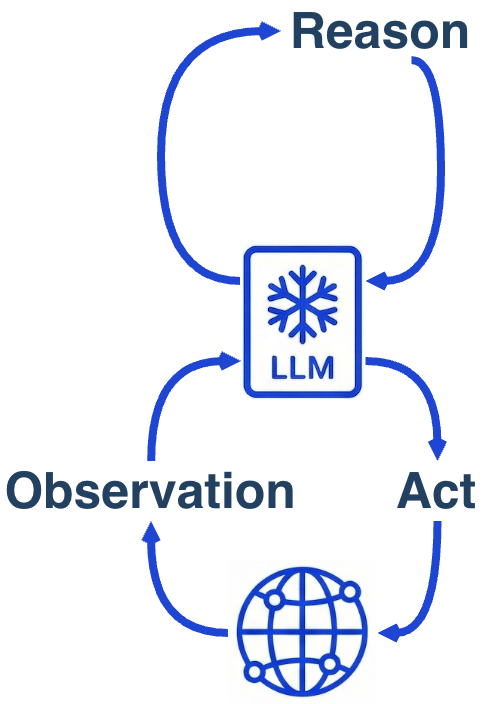


Сначала она рассуждает, что нужно сделать, затем выполняет действие (через инструменты), получает результат и только после этого выбирает следующий шаг. В терминах цикла это думать (reason), действовать (act), наблюдать (observe).

Преимущество ReAct в том, что процесс становится более прозрачным: мы видим цепочку шагов и действий агента (план, вызовы инструментов, результаты) и можем контролировать ход работы. Это один из базовых паттернов, на котором строятся многие современные агенты.

### Lang ...

LangChain и LangGraph это конкретно фреймворки, написанные одной core-командой, 

LangSmith — платный трейсинг, 

LangFuse — сторонний опенсурсный трейсинг, LangFlow — визуальный билдер агентов. 



### LangChain

https://docs.langchain.com/oss/python/langchain/quickstart

LangChain — это модульный фреймворк для создания приложений на базе LLM. 

Он дает нам строительные кубики (промпты, модели, память, инструменты, ретриверы) и простой способ соединить их в цепочку вызовов. 

Идеально хорош для линейных пайплайнов, но и сложные вещи на нем тоже делать можно — чат-боты, агенты с инструментами, RAG и так далее.".

### LangGraph

https://docs.langchain.com/oss/python/langgraph/

LangGraph — это отдельный фреймворк, по сути продолжении идеи и графовый фреймворк (может использовать компоненты LangChain, но работает независимо). Вместо цепочек здесь граф с узлами (действия) и ребрами (переходы), где объект состояния путешествует по графу. 

Такой дизайн позволяет собирать систему любой сложности: нативно есть ветвления (для выбора разных путей), циклы (задавать уточняющие вопросы), делать повторы (при каких-либо ошибках) и паузы под получение обратной связи от пользователя.

У LangChain/LangGraph общее ядро и поверх нюансы конкретного фреймворка . В нем несколько слоев абстракции и модульная архитектура:

1. 
langchain-core — фундаментальный слой, одинаковый для обои
  
  - Б

Базовые абстракции для LLM, chat models, embeddings, парс
  - га

Runnable protocol — фундаментальный интерфейс, лежащий в основе всех компоне--нтов

In-memory реализации ключевых кон--цепций

Интеграционные пакеты (langchain-openai, langchain-anthropic-  и т.д.)

LangChain: +пакет -- langchain:

Готовые цепочки, функционал агентов и стратег-- ии retrieval

Готовые высокоуровневые компоненты (RetrievalQA, ConversationChain, агент- ы и так далее)

LangGraph: +--  пакет langgraph

Графовая система оркестрации п--оверх того же core

Стейт-машина, чекпоинтинг, мультиагентность (и гораздо меньше готовых компонентов)7

### Интерфейс Runnable

Интерфейс Runnable - основа основ для работы со всеми компонентами LangChain. Его реализуют практически все сущности, с которыми нам придется работать.

Основные методы, которые предоставляет интерфейс:

- invoke/ainvoke: преобразует одиночный входной сигнал в выходной, используется для вызова сущностей, например, языковых моделей.

- batch/abatch: преобразует множество входных данных в выходные.

- stream/astream: потоковая передача выходных данных с одного входного сигнала.

- ainvoke, abatch, astream - асинхронные вариации.

### Язык выражений LangChain (LCEL)


Одно из главных преимуществ фреймворка - возможность объединять создаваемые сущности в последовательные "цепочки", где выходные данные одного элемента служат входными данными для следующего.

Давайте разными способами напишем небольшой пример с использованием цепочки:

- RunnableLambda - преобразует вызываемый объект Python в Runnable, который предоставляет преимущества LangChain.

- RunnableSequence - самый важный оператор композиции, поскольку он используется в каждой цепочке и реализует интерфейс Runnable,поэтому для него доступны методы invoke, batch и т.д.

In [ ]:
from langchain_core.runnables import RunnableLambda, RunnableSequence

runnable1 = RunnableLambda(lambda x: x + 1)
runnable2 = RunnableLambda(lambda x: x + 2)

#создаем цепочку из двух обьект RunnableLambda
chain = RunnableSequence(runnable1, runnable2)

#вызывваем цепочку
print(chain.invoke(2)) 

Без использования RunnableSequence

In [ ]:
langchain_core.runnables import RunnableLambda

runnable1 = RunnableLambda(lambda x: x + 1)
runnable2 = RunnableLambda(lambda x: x + 2)

output1 = runnable1.invoke(2)
output2 = runnable2.invoke(output1)

print(output2)


С использованием LCEL ("|")

In [ ]:
from langchain_core.runnables import RunnableLambda

runnable1 = RunnableLambda(lambda x: x + 1)
runnable2 = RunnableLambda(lambda x: x + 2)

chain = runnable1 | runnable2
print(chain.invoke(2))  # 5

...

### Мини-выводы про LangChain:

У LangChain большое количество удобных и продуманных штук, которых достаточно чтобы в него запихать не просто линейную логику, но и многие сложные вещи. Пописать код для чего-то кастомного — ну да, придется, но в целом все достаточно приятно.

Но если нужно из коробки сразу все самое сложное, задача решается графами, есть очень сложный план, которого надо придерживаться или есть мультиагентность, то под это подойдет LangGraph.

### Как устроен LangGraph


Для аналогии можно представить LangGraph как блок-схему нашего приложения. Каждый блок (узел = «node») — это просто маленькая функция на питошке, которая выполняет одну задачу. Стрелки (ребра = «edges») говорят, какой блок запускается следующим. По блок-схеме как бы перемещается «рюкзачок с данными» (состояние = «state») и в этот рюкзачок можно что-то положить и что-то считать. В чат-ботах там лежит, как правило, список сообщений чата

LangChain работает с цепочками (chains), LangGraph — с графами состояний (graphs). 

Цепочки хороши для линейных пайплайнов, графы — для сложной мультиагентной оркестрации с циклами и ветвлениями. Почти все сложное, что нативно сделано в коробке LangGraph МОЖНО сделать на LangChain, но это будет неудобно (сложная логика), запутанно (вложенные друг в друга RunnableBranch), а то и совсем на костылях (типа human-in-the-loop или по простому — запроса данных от пользователя).
.

## LangSmith и LangFuse

В любом софте всегда может произойти что-то странное и необъяснимое, а в софте с LLM это фактически базово-ожидаемое поведение. И чтобы такого происходило меньше или чтобы уметь объяснять это необъяснимое, нам необходим трейсин

г. Конечно, любой трейсинг можно сделать самостоятельно, но это бывает часто не так-то просто и точно всегда приводит к ухудшению читаемости кода. Поэтому трейсинг из коробки на уровне фреймворка — то, что доктор прописал.

LangChain и LangGraph — это семейство фреймворков, выпущенных одной коман
дой. И эта же команда сделала сервис LangSmith, который нативно умеет все делать на уровне я
дра. С ним замечательно все, кроме того, что он платный, SaaS-only и под другие фреймворки все уже не так нативно, а через sdk.

В качестве ответа такому безобразию от сторонней команды появился LangFuse — open-source альтернатива для трейсинга LLM-прило
жений. Его главное преимущество — on-premise, то есть его можно развернуть у себя. LangFuse работает не на уровне ядра и требует подключения через колбеки или декораторы.

## Мультиагентные системы

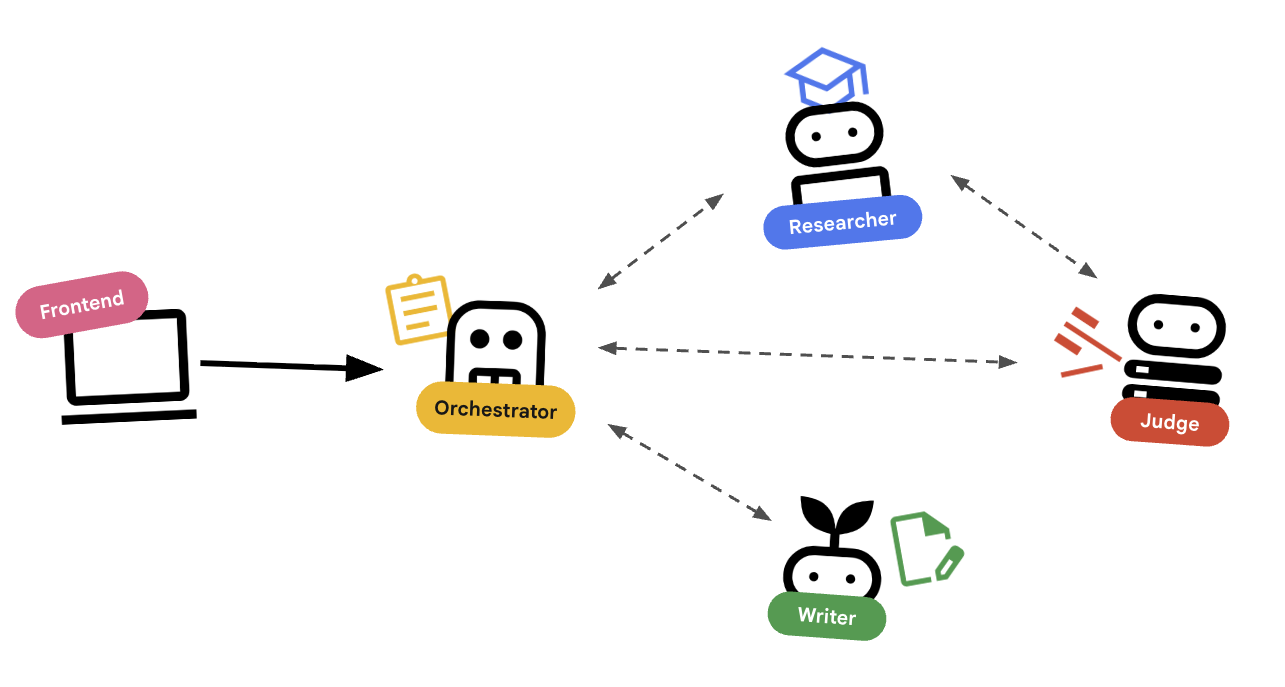

Мультиагентная система (MAS, Multi-Agent System) — это система из нескольких агентов, которые координируют действия и совместно решают одну задачу. Идея похожа на команду: вместо одного универсального исполнителя есть несколько ролей (например, планировщик, исследователь, исполнитель и валидатор), а результаты собираются в общий ответ. 

Почему это бывает полезно? 

1. появляется параллелизм: разные агенты могут одновременно выполнять подзадачи.
2. повышается качество: агенты могут взаимно проверять результаты, что снижает риск ошибок.
3. становится проще масштабировать сложные сценарии со множеством инструментов, источников данных и промежуточных шагов. 

## Архитектуры MAS:


### Оркестратор

Как работает:

Supervisor получает задачу

Решает, какому worker'у поручить

Worker возвращает результат

Supervisor решает: завершить или передать дальше

        ┌─────────────┐
        │ Supervisor  │
        └──────┬──────┘
       ┌───────┼───────────────┐
       ▼       ▼               ▼
┌──────────┐ ┌──────────┐ ┌──────────┐
│ Worker 1 │ │ Worker 2 │ │ Worker 3 │
└──────────┘ └──────────┘    └──────────┘──────┘
-

### Групповая дискуссия

┌──────────┐    ┌──────────┐
│ Agent A  │◄──►│ Agent B  │
└────┬─────┘    └────┬─────┘
     │               │
     ▼               ▼
┌──────────┐    ┌──────────┐
│ Agent C  │◄──►│ Agent D  │
└──────────┘    └────

Вариации:

Debate: Агенты спорят, приходят к консенсусу

Round-robin: По очереди высказываются, накапливая общее решение

Marketplace: Агенты предлагают услуги друг д
ругу

Когда использовать: Задачи, требующие множества перспектив (анализ, креатив, оценка рисков).

Примеры реализации: AutoGen (Microsoft) — встроенная поддержка группового чата.──────┘

### Иерархия

           ┌──────────────┐
           │ Top Manager  │
           └──────┬───────┘
          ┌───────┴───────┐
          ▼               ▼
    ┌──────────┐     ┌──────────┐
    │Manager 1 │     │Manager 2 │
    └────┬─────┘     └────┬─────┘
    ┌────┴────┐       ┌────┴────┐
    ▼         ▼       ▼         ▼
  W1        W2      W3


  Когда использовать: Огромные сложные задачи с естественной вложенной структурой (например, разработка целого проекта: архитектор → тимлиды → разработчики).        W4

###  Dynamic (Роевой / Динамический)

Схема: Нет фиксированной структуры. Агенты появляются, исчезают, создают друг друга динамически.

Особенности:

Агент может породить нового агента для подзадачи

Нет центрального контроллёра

Самоорганизация

Когда использовать: Исследовательские задачи, где структура заранее неизвестна.

Пример: BabyAGI, AutoGPT (ранние версии) — агент создаёт задачи, а для каждой задачи — нового агента.

### Плюсы мультиагентных систем
1. Специализация — каждый агент настраивается под свою узкую задачу (разные системные промпты, разные модели, разная температура).
2. Масштабирование — можно добавить нового агента, не трогая остальных.
3. Отказоустойчивость — если один агент упал, остальные продолжают работу (в хороших реализациях).
4. Разные модели — один агент на GigaChat, другой на маленькой локальной модели для быстрых операций.
5. Параллелизм — независимые агенты работают одновременно.
6. Дебат улучшает качество — несколько агентов, обсуждающих ответ, дают более надёжный результат (исследования от Google и Anthropic).

### Минусы мультиагентных систем
1. Сложность отладки — вы не знаете, почему агент A сказал агенту B сделать X. Трейсинг (LangFuse) становится не опцией, а необходимостью.
2. Латенси — каждый round-trip между агентами — это отдельный LLM-вызов. 3 агента по 2 раунда = 6 вызовов.
3. Cost — больше вызовов = больше токенов = больше денег.
4. Нестабильность — чем больше агентов, тем выше шанс, что один уйдёт в бесконечный цикл или галлюцинацию.
5. Голосование и консенсус — если агенты не согласны, нужен механизм разрешения конфликтов (ещё один агент?).


https://codelabs.developers.google.com/codelabs/production-ready-ai-roadshow/1-building-a-multi-agent-system/building-a-multi-agent-system?hl=ru#0

### Вертикальные и горизонтальные агенты

Сейчас в области AI-агентов активно развиваются два направления:

1. Вертикальное — как сделать каждого агента сильнее. Сюда относятся самосовершенствующиеся системы вроде Hyperagents, Ouroboros, EvoAgent, ADAS — агент рекурсивно улучшает сам себя.

2. Горизонтальное — как группа агентов координируется вместе. Не один агент становится умнее, а многие агенты начинают работать как единое целое.

# Тренды в Агентах

## Skills vs MCP

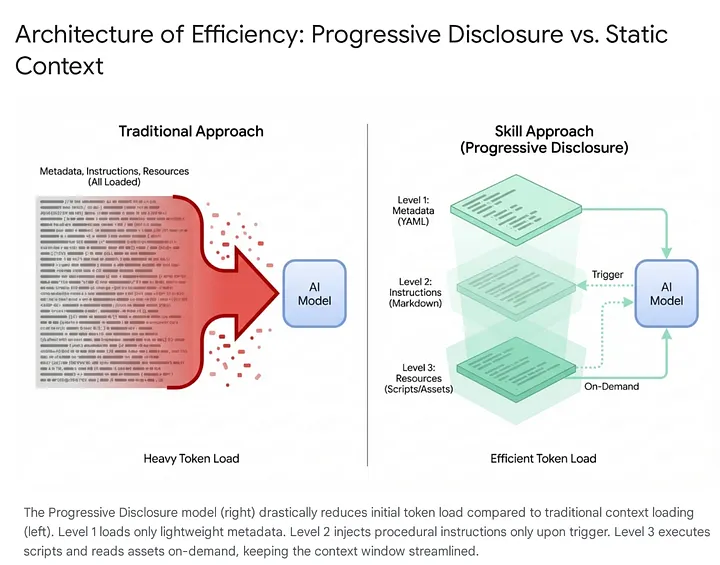

Хотя современные модели, такие как Gemini 2.5/3, могут похвастаться контекстными окнами размером более миллиона токенов, бездумная загрузка в активную память модели всего кодовой базы, документации и набора инструментов приводит к серьёзным задержкам и финансовым издержкам. 

Agent Skills (навыки агентов) - это новый архитектурный паттерн для LLM-агентов, позволяющий имитировать наличие у модели набора узкоспециализированных компетенций.

Навыки агентов предлагают изящное решение: ввести единицу стандартизации - переносимый, версионируемый пакет процедурного знания, который можно поддерживать как код и подключать к агенту как библиотеку. С появлением Agent Skills мы перестаем объяснять ИИ как действовать правильно всякий раз с нуля - мы один раз оформляем навык и затем переиспользуем его повсеместно. Когда подобные навыки становятся частью экосистемы, AI-ассистент начинает работать по проверенным инструкциям, вместо разрозненных подсказок


### Skills и Model Context Protocol (MCP)

Одним из самых распространённых источников путаницы является различие между Skills и Model Context Protocol (MCP). Оба механизма расширяют возможности агента, но решают разные задачи и используют разные архитектурные подходы.

Antigravity Skills лучше всего понимать как лёгкие, эфемерные определения задач. Они не требуют серверов и основаны на файла
х. При вызове skill агент читает инструкции и при необходимости выполняет скрипт. После завершения задачи контекст skill освобождается. Это делает их идеальными для разовых инженерных задач вроде «сгенерировать changelog», «запустить конкретный набор тестов» или «отформатировать код». Они не требуют постоянной инфраструктуры и могут версионироваться вместе с кодом, над которым работают.

Model Context Protocol (MCP), напротив, — это тяжёлый стандарт взаимодействия. Он предполагает клиент-серверную архитектуру, в которой IDE подключается к работающему серверному процессу. MCP предназначен для поддержания состояния при работе с внешними системами — такими как базы данных PostgreSQL, репозитории GitHub или рабочие пространства Slack. MCP-сервер поддерживает постоянное соединение, управляет состоянием аутентификации и предоставляет агенту динамический набор инструментов и ресурсов. При всей своей мощи этот подход влечёт за собой операционные издержки: потребление памяти работающими процессами, управление портами и усложнение жизненного цикла.

Философия Skills: Skills отражают сдвиг в сторону принципа «меньше инфраструктуры — больше интеллекта». Вместо поддержки сложной сети микросервисов только ради того, чтобы ИИ мог прочитать схему базы данных, Skill может просто содержать скрипт, который подключается, считывает данные и отключается. Эта эфемерная природа делает Skills идеальными для подавляющего большинства локальных задач разработки, где постоянные соединения — избыточная нагр- уровне:

MCP Tools — это руки: детерминированные функции вроде read_file, execute_query или s- arch_web.

Skills — это мозг: методология, которая определяет, как и когда агенту использовать эти инструменты.

## Openclaw 

- он не привязан к одному провайдеру ИИ: сверху можешь использовать разные модели (Claude, GPT, DeepSeek и т.д.);
- он **разворачивается у тебя** — на своём сервере, VPS или через облачный инстанс, но под твоим контролем;
- общение идёт через привычные каналы: Telegram, Discord, WhatsApp, Signal и т.п.;
- внутри у него уже есть «мозги и руки»: агентный слой с памятью, задачами, доступом к API и файл

это не просто бот, а **фреймворк агента**, который ты приручаешь под свои сценарии.ам.

Итого: простая комбинация из долгоживущего gateway-процесса + LLM + заметок в текстовых файлах + cron-задач - создаёт полное впечатление сознательного существа. Это заставляет задуматься - а мы сами то не то же самое?..ся?

На самом деле он может делать очень сложные вещи - например, совершенствовать самого себя, если вы попросите добавить навыки, которых у него нет. Он может создавать и запускать сложные рабочие процессы: например, собирать самые популярные видео на YouTube по теме, транскрибировать их, анализировать и суммировать ключевые выводы и отправлять вам на почту каждое утро.

https://habr.com/ru/articles/1017200/

https://cloud.google.com/discover/what-are-ai-agents
https://cloud.google.com/resources/content/building-ai-agents

https://huggingface.co/learn/agents-course/unit0/introduction

https://www.kaggle.com/learn-guide/5-day-genai
https://www.kaggle.com/learn-guide/5-day-agents

## Ссылка на ноутбук команды GigaChain

https://habr.com/ru/companies/sberbank/articles/941340/

## Пятидневный интенсив от гугл

https://habr.com/ru/articles/964888/

# Полезные ссылки

https://aistudio.yandex.ru/docs/en/ai-studio/operations/index.html
https://developers.sber.ru/docs/ru/gigachat/individuals-quickstart

https://github.com/ai-forever/gigachain

https://habr.com/ru/articles/962852/
